<a href="https://colab.research.google.com/github/boryanakostadinova87-cyber/Final-Project-1/blob/main/DS_FinalProject2_Kostadinova_6235174.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Skills - Final Project 2
## Who is about to leave? Predicting customer churn

**Prof. Juan Martin Maglione**

---

**Name:** Boryana Kostadinova

**Student number:** 6235174

**Date:** 09.10.2026


### Before you start

Read the guidelines document first. It explains the dataset, the deliverable and the rules. Short version:

1. Download the dataset from Kaggle (link in the guidelines), rename the csv to `telco_churn.csv`, and upload it to your Colab session, or place it in the same folder as this notebook if you work locally.
2. Work through the parts in order. Every part builds on the previous one, and the models in Part 5 only work if Parts 2 and 4 were done right.
3. Where a task asks for a written answer, write it in a text cell in your own words. Pasting output into a text cell is not a written answer.
4. Before submitting, go to Runtime > Restart session and run all. Every cell must run without errors and every chart must be visible. If it crashes halfway, fix it: a notebook that does not run from top to bottom is not finished work.

Each part lists the functions you will probably need. That is on purpose: looking up how a function works, reading one example and trying it out is part of the exercise.

Many tasks show what the expected output should look like. The `X` characters in those examples are placeholders: your output must have the same structure, filled with the real numbers from the data.


## Part 0 - Setup

Two things happen in the cell below, and nothing else:

1. Import pandas, numpy and matplotlib.pyplot with their usual short names (`pd`, `np`, `plt`).
2. Load `telco_churn.csv` into a DataFrame and call it `df`. Use exactly that name, every later part assumes it.

The file comes from Kaggle under the unpronounceable name `WA_Fn-UseC_-Telco-Customer-Churn.csv`. Rename it to `telco_churn.csv` before uploading, exactly as the guidelines say, so this notebook finds it.

Functions you will probably need: `pd.read_csv()`


In [23]:
# Part 0 - imports and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("telco_churn.csv")

## Part 1 - First look, and the question we are asking

Each row is one customer of a telecom provider. The last column, `Churn`, says whether that customer cancelled the service. The whole project is one question: can we predict, from what we know about a customer, whether they are about to leave? Before any model, get to know the table and the target. One code cell per step.

**1.1** Print one readable line stating how many rows and how many columns the dataset has, in this structure, then show the first 5 rows:

```
This dataset has XXXX rows and XX columns.
```

**1.2** Show the overview of all columns with their data types and non-missing counts. One function does all of that at once. Look carefully at the types; step 1.5 will ask about them.

**1.3** How many customers churned and how many stayed? Show the counts, then print one sentence with the churn percentage rounded to one decimal:

```
XX.X percent of the customers in this dataset churned.
```

**1.4** The laziest possible model predicts "No churn" for every single customer and never looks at the data. What accuracy does it get? Print it in this structure, and store the number in a variable called `baseline`, because Part 5 will need it:

```
A model that always predicts No churn is right XX.X percent of the time.
```

**1.5** Answer in the text cell below, in three to five full sentences: (a) which column that clearly holds amounts of money is stored as text instead of a number, (b) what that usually means is hiding inside such a column, and (c) why the number from 1.4 is the bar that any model in this project has to beat.

Functions you will probably need: `.shape`, `.head()`, `.info()`, `.value_counts()` (check its `normalize` parameter), `round()`


In [24]:
# 1.1 - one printed line with rows and columns, then first 5 rows
print(f"This dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

This dataset has 7043 rows and 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
# 1.2 - column overview with data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
# 1.3 - churn counts + percentage sentence
print(df["Churn"].value_counts())

churn_percentage = df["Churn"].value_counts(normalize=True)["Yes"] * 100

print(f"{churn_percentage:.1f} percent of the customers in this dataset churned.")

Churn
No     5174
Yes    1869
Name: count, dtype: int64
26.5 percent of the customers in this dataset churned.


In [27]:
# 1.4 - baseline accuracy of always predicting No churn (store it in a variable)
baseline = (df["Churn"] == "No").mean()

print(f"A model that always predicts No churn is right {baseline * 100:.1f} percent of the time.")

A model that always predicts No churn is right 73.5 percent of the time.


**Your answer for 1.5:**

The TotalCharges column contains amounts of money, but it is stored as text instead of numbers. This can mean that some values are empty or contain unexpected characters, which prevents Python from treating the entire column as numerical data. The baseline accuracy is approximately 73.5% and any other model should be compared to this baseline to determine whether it can predict churn better than simply assuming that every customer will stay.


## Part 2 - Cleaning and preparation

A model is only as good as the table it learns from, so the table goes first. Follow the steps in order; each one states exactly what must be true when you are done.

**2.1** Convert `TotalCharges` to a numeric column. The broken values inside it cannot be converted, so tell pandas to turn everything unconvertible into a missing value instead of crashing. Then count how many broken values you found and print:

```
Broken values found: XX
```

**2.2** Play detective before you repair anything. Show `tenure`, `MonthlyCharges` and `TotalCharges` for exactly the rows where `TotalCharges` is now missing, and look at what they have in common. These are customers who joined this month and have not paid a single bill yet, so their true total is not unknown, it is zero. Fill the missing values with 0, not with an average, and finish with a check:

```
Missing values left in TotalCharges: 0
```

**2.3** The target `Churn` contains the text values "Yes" and "No". The model and every metric in Part 5 need numbers. Convert the column so that "Yes" becomes 1 and "No" becomes 0, and show the counts afterwards to confirm nothing was lost. A pleasant side effect you will use in Part 3: the mean of a 1/0 column is exactly the share of ones, so `df["Churn"].mean()` is the churn rate.

**2.4** `customerID` identifies a customer but describes nothing about them. A model must not learn from it: at best it is noise, at worst the model memorizes IDs instead of patterns. Remove the column and print:

```
Columns left: XX
```

**2.5** Prove the cleaning worked: show the column overview again. Three things must be true: `TotalCharges` is a float, `Churn` is an integer, and `customerID` is gone.

Functions you will probably need: `pd.to_numeric(..., errors="coerce")`, `.isna()`, `.sum()`, `.fillna()`, `.map()`, `.drop(columns=...)`, `.info()`


In [28]:
# 2.1 - TotalCharges to numeric + count broken values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

broken_values = df["TotalCharges"].isna().sum()

print(f"Broken values found: {broken_values}")

Broken values found: 11


In [29]:
# 2.2 - inspect the broken rows, fill with 0, check
df.loc[df["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "TotalCharges"]]
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(f"Missing values left in TotalCharges: {df['TotalCharges'].isna().sum()}")


Missing values left in TotalCharges: 0


In [30]:
# 2.3 - Churn to 1/0 + counts check
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())


Churn
0    5174
1    1869
Name: count, dtype: int64


In [31]:
# 2.4 - drop customerID + columns left
df = df.drop(columns=["customerID"])

print(f"Columns left: {df.shape[1]}")

Columns left: 20


In [32]:
# 2.5 - verify: types and columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## Part 3 - What drives churn

Before predicting who leaves, look at who has been leaving. Chart rules are the same as in the first project: a title, labels on both axes with units where relevant, a `figsize` you set yourself, at least one custom color somewhere in this part, and `plt.show()` at the end of every chart cell.

**3.1** Compute the churn rate per contract type, as a percentage, sorted from highest to lowest. Use the 1/0 trick from 2.3. Then print one sentence naming the worst one:

```
<contract type> customers churn the most: XX.X percent of them left.
```

**3.2** The same churn rate per category of `InternetService`, as a percentage, sorted from highest to lowest. No sentence needed, but remember what you see here for Part 6.

**3.3** A bar chart of the churn rate per contract type, using your result from 3.1. X axis: the three contract types. Y axis: churn rate in percent.

**3.4** One chart with two histograms of `tenure` (how many months a customer has been with the company): one for customers who stayed, one for customers who churned, drawn on top of each other. Make both visible with the `alpha` parameter, give each a label, and add a legend. This chart answers a question the numbers alone do not: when do customers leave?

Functions you will probably need: `.groupby()`, `.mean()`, `.sort_values()`, `.idxmax()`, `plt.bar()`, `plt.hist(alpha=..., label=...)`, `plt.legend()`


In [33]:
# 3.1 - churn rate per contract type (%) + sentence
contract_churn = (
    df.groupby("Contract")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(contract_churn)

worst_contract = contract_churn.idxmax()
worst_rate = contract_churn.max()

print(f"{worst_contract} customers churn the most: {worst_rate:.1f} percent of them left.")


Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64
Month-to-month customers churn the most: 42.7 percent of them left.


In [34]:
# 3.2 - churn rate per internet service (%)
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(internet_churn)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


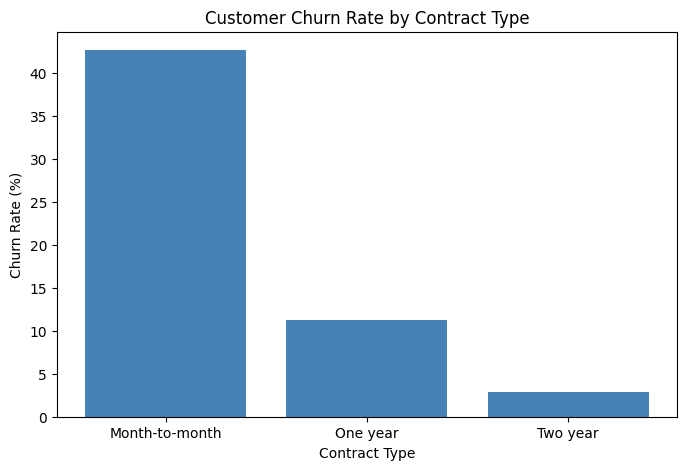

In [35]:
# 3.3 - bar chart: churn rate by contract type
plt.figure(figsize=(8, 5))

plt.bar(contract_churn.index, contract_churn.values, color="steelblue")

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

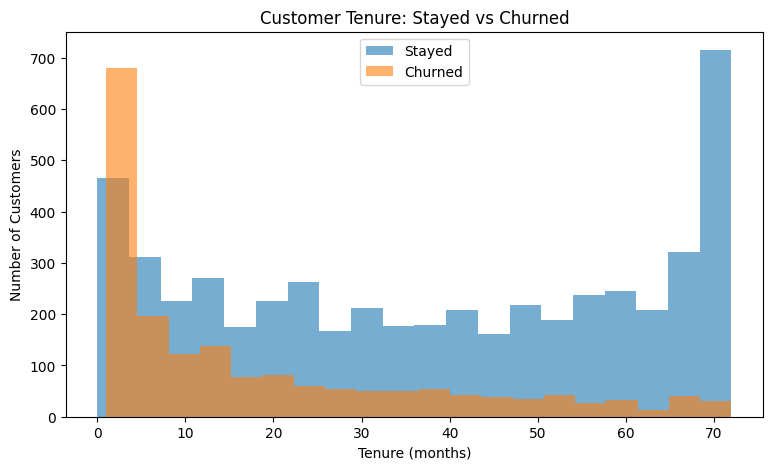

In [36]:
# 3.4 - two histograms of tenure: stayed vs churned
plt.figure(figsize=(9, 5))

plt.hist(
    df.loc[df["Churn"] == 0, "tenure"],
    bins=20,
    alpha=0.6,
    label="Stayed"
)

plt.hist(
    df.loc[df["Churn"] == 1, "tenure"],
    bins=20,
    alpha=0.6,
    label="Churned"
)

plt.title("Customer Tenure: Stayed vs Churned")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

## Part 4 - From table to training data

Two things stand between the cleaned table and a model. First, models compute with numbers only, and most of this table is text. Second, a model must be judged on data it has never seen, otherwise you are testing memory, not prediction.

**4.1** Separate the target from the features: `y` is the `Churn` column, `X` is everything else. Print the shape of both.

**4.2** Encode the text columns: `pd.get_dummies(X)` turns every text column into 0/1 columns, one per category, and leaves numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`, and `SeniorCitizen`, which arrived already encoded) untouched. Overwrite `X` with the encoded version, look at the first rows to see what happened, and print:

```
After encoding, X has XX columns.
```

Depending on your pandas version the new columns show True/False instead of 1/0. Both are fine, the models read them the same way.

**4.3** Split into training and test data with `train_test_split`, using `test_size=0.2`, `random_state=42` and `stratify=y`. The `random_state` makes the split reproducible, so your numbers match mine; `stratify=y` keeps the churn share identical in both pieces, so the test is fair. Print the four shapes, then prove the stratification worked:

```
X_train: (XXXX, XX)   X_test: (XXXX, XX)
y_train: (XXXX,)   y_test: (XXXX,)
Churn share in training data: XX.X percent
Churn share in test data: XX.X percent
```

From this point on, one rule is absolute: the test set stays in a drawer. Every model is trained on the training data only, and touches the test data exactly once, to be judged.

Functions you will probably need: `pd.get_dummies()`, and this import: `from sklearn.model_selection import train_test_split`


In [37]:
# 4.1 - X and y + shapes
y = df["Churn"]
X = df.drop(columns=["Churn"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [38]:
# 4.2 - encode text columns with get_dummies + column count
X = pd.get_dummies(X)

print(X.head())
print(f"After encoding, X has {X.shape[1]} columns.")

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Female  \
0              0       1           29.85         29.85           True   
1              0      34           56.95       1889.50          False   
2              0       2           53.85        108.15          False   
3              0      45           42.30       1840.75          False   
4              0       2           70.70        151.65           True   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  Dependents_Yes  ...  \
0        False       False         True           True           False  ...   
1         True        True        False           True           False  ...   
2         True        True        False           True           False  ...   
3         True        True        False           True           False  ...   
4        False        True        False           True           False  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0               

In [39]:
# 4.3 - train/test split + shapes + churn share in both pieces
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}   y_test: {y_test.shape}")

print(f"Churn share in training data: {y_train.mean() * 100:.1f} percent")
print(f"Churn share in test data: {y_test.mean() * 100:.1f} percent")


X_train: (5634, 45)   X_test: (1409, 45)
y_train: (5634,)   y_test: (1409,)
Churn share in training data: 26.5 percent
Churn share in test data: 26.5 percent


## Part 5 - Train two models and judge them honestly

Same recipe for every scikit-learn model: create it, `fit` it on the training data, `score` it wherever you want an accuracy. Three lines per model. The thinking is in reading the numbers, not in writing the code.

**5.1** Train a decision tree: `DecisionTreeClassifier(random_state=42)`, fit on the training data. Then print its accuracy on the training data and on the test data, both rounded to three decimals:

```
Decision tree - accuracy on training data: X.XXX
Decision tree - accuracy on test data: X.XXX
```

**5.2** Look at those two numbers and answer in the text cell below, in two or three sentences: what is the tree doing on the training data, what happens on data it has never seen, and what is the name of this phenomenon? The name is a standard term; if you do not know it, this is exactly the kind of thing to look up.

**5.3** Train a logistic regression: `LogisticRegression(max_iter=5000)`, fit on the training data. Print the same two accuracy lines as in 5.1, then one closing sentence that uses your `baseline` variable from 1.4:

```
Logistic regression - accuracy on training data: X.XXX
Logistic regression - accuracy on test data: X.XXX
<model name> wins on the test data with XX.X percent, against a baseline of XX.X percent.
```

**5.4** Take the winner from 5.3 and put it under the microscope. Let it predict the test set, then show the confusion matrix with a printed line above it explaining how to read it (rows are the actual values, columns the predicted ones). Then print precision and recall, rounded to three decimals:

```
Confusion matrix (rows: actual, columns: predicted)
[[XXX  XXX]
 [XXX  XXX]]

Precision: X.XXX
Recall: X.XXX
```

Answer in the text cell below 5.4, in three or four sentences: out of all the customers in the test set who really churned, how many did the model catch and how many slipped through? For a subscription business, what is the difference in cost between missing a churner and falsely alarming on a loyal customer?

**5.5** Numbers with faces. Write a function `check_customer(model, X_test, y_test, position)` with exactly those four parameters, that takes one customer from the test set by position and prints this report:

```
Customer at position X
  Predicted: Churn
  Actual: No churn
  The model got this one wrong.
```

The last line must adapt: "right" when prediction and reality agree, "wrong" when they do not, and the labels must read "Churn" and "No churn", not 1 and 0. Hint: `X_test.iloc[[position]]` with double brackets hands the model one row in the shape it expects. Then call your function for three different positions using a for loop.

Functions you will probably need: `.fit()`, `.score()`, `.predict()`, and these imports: `from sklearn.tree import DecisionTreeClassifier`, `from sklearn.linear_model import LogisticRegression`, `from sklearn.metrics import confusion_matrix, precision_score, recall_score`


In [40]:
# 5.1 - decision tree: fit + accuracy on training and test data
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

print(f"Decision tree - accuracy on training data: {tree_model.score(X_train, y_train):.3f}")
print(f"Decision tree - accuracy on test data: {tree_model.score(X_test, y_test):.3f}")

Decision tree - accuracy on training data: 0.998
Decision tree - accuracy on test data: 0.720


**Your answer for 5.2:**

The decision tree achieves 99.8% accuracy on the training data but only 72.0% on the test data. This means that it learns the training data very well but does not perform as well on new, unseen customers. The phenomenon is called overfitting.


In [41]:
# 5.3 - logistic regression: fit + accuracies + winner sentence
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

tree_test_accuracy = tree_model.score(X_test, y_test)
log_test_accuracy = log_model.score(X_test, y_test)

print(f"Logistic regression - accuracy on training data: {log_model.score(X_train, y_train):.3f}")
print(f"Logistic regression - accuracy on test data: {log_test_accuracy:.3f}")

winner_name = "Logistic regression" if log_test_accuracy >= tree_test_accuracy else "Decision tree"

print(f"{winner_name} wins on the test data with {max(log_test_accuracy, tree_test_accuracy) * 100:.1f} percent, against a baseline of {baseline * 100:.1f} percent.")


Logistic regression - accuracy on training data: 0.807
Logistic regression - accuracy on test data: 0.807
Logistic regression wins on the test data with 80.7 percent, against a baseline of 73.5 percent.


In [42]:
# 5.4 - confusion matrix + precision + recall of the winner
from sklearn.metrics import confusion_matrix, precision_score, recall_score

winner_model = log_model if log_test_accuracy >= tree_test_accuracy else tree_model
predictions = winner_model.predict(X_test)

print("Confusion matrix (rows: actual, columns: predicted)")
print(confusion_matrix(y_test, predictions))

print(f"\nPrecision: {precision_score(y_test, predictions):.3f}")
print(f"Recall: {recall_score(y_test, predictions):.3f}")


Confusion matrix (rows: actual, columns: predicted)
[[927 108]
 [164 210]]

Precision: 0.660
Recall: 0.561


**Your answer for 5.4:**

The logistic regression model correctly identified 210 out of 374 customers who actually churned, but it missed 164 customers who left. Missing a customer who is likely to leave can result in lost revenue for the company, while falsely identifying a loyal customer as likely to leave can waste time and resources.


In [43]:
# 5.5 - check_customer function + loop over three positions
def check_customer(model, X_test, y_test, position):
    customer = X_test.iloc[[position]]
    prediction = model.predict(customer)[0]
    actual = y_test.iloc[position]

    predicted_label = "Churn" if prediction == 1 else "No churn"
    actual_label = "Churn" if actual == 1 else "No churn"
    result = "right" if prediction == actual else "wrong"

    print(f"Customer at position {position}")
    print(f"  Predicted: {predicted_label}")
    print(f"  Actual: {actual_label}")
    print(f"  The model got this one {result}.")


for position in [0, 1, 2]:
    check_customer(winner_model, X_test, y_test, position)


Customer at position 0
  Predicted: No churn
  Actual: No churn
  The model got this one right.
Customer at position 1
  Predicted: Churn
  Actual: No churn
  The model got this one wrong.
Customer at position 2
  Predicted: No churn
  Actual: No churn
  The model got this one right.


## Part 6 - Insights

The point of all this work is to go from data to information to insight. Parts 1 to 5 gave you the information. Now write five insights in the text cell below.

Rules for each insight:

- Exactly two sentences.
- The first sentence states what the data or the model shows and contains at least one number from your own results above.
- The second sentence says why that could matter, for the company, for a customer, for whoever runs retention. This is your interpretation; there is no single right answer, but there must be an answer.
- At least one insight must be about model quality (Part 5) and at least one about what drives churn (Part 3). The five together must come from different findings, not the same finding five times.

An observation without a number is an opinion, and a number without a "so what" is trivia.

Example of the expected level (do not reuse it): "The model catches roughly half of the customers who actually leave, while a always-no model catches none. Half is far from perfect, but for a retention team it is the difference between calling blindly and calling a list where every second name is right."


**Insight 1:** Model performance- The logistic regression model achieved 80.7% accuracy on the test data, compared with the baseline accuracy of 73.5%. This shows that the model can predict customer churn better than simply assuming that every customer will stay.

**Insight 2:** What drives churn- The contract type appears to be an important factor in customer churn, as 42.7% of month-to-month customers left compared with only 2.8% of customers with a two-year contract. This suggests that the company should focus on understanding the needs of month-to-month customers and finding ways to encourage them to stay longer.

**Insight 3:** Internet service- Customers with fiber optic internet had a churn rate of 41.9%, while the rate for DSL customers was 19.0%. The company should investigate why fiber optic customers leave more often and whether pricing or service quality could be contributing factors.

**Insight 4:** Model limitations- The logistic regression model correctly identified 210 of the 374 customers who actually churned, but it missed 164. The company should use the model as a helpful tool for identifying at-risk customers rather than relying on it to find every customer who might leave.

**Insight 5:** Overfitting-
The decision tree achieved 99.8% accuracy on the training data but only 72.0% on the test data. This indicates overfitting, meaning the model performs very well on data it has already seen but struggles to generalize to new customers.

## Bonus - Teach the tree some restraint (optional)

For when the six parts are done and you want more. The tree from 5.1 was allowed to grow without limits, and you saw in 5.2 what that leads to. The `max_depth` parameter caps how deep it may grow. Find the depth where it performs best on data it has never seen:

1. Loop over depths 1 to 15. For each depth, train `DecisionTreeClassifier(max_depth=depth, random_state=42)` on the training data and store its training accuracy and its test accuracy in two lists.
2. Draw one line chart with both lists against depth: two lines, markers on the points, a legend, a grid, and the usual title and axis labels.
3. Print the winner:

```
Best depth on the test data: X with accuracy X.XXX
```

Read your own chart before you close the notebook: the training line keeps climbing forever, the test line rises and then bends down. The point where they part ways is 5.2, drawn as a picture.


In [44]:
# Bonus (optional) - max_depth loop + chart + best depth


---
## Before you hand it in

1. Your name and student number are at the top.
2. Runtime > Restart session and run all. No errors, all charts visible.
3. Every output that had a prescribed structure follows it.
4. All text answers (1.5, 5.2, 5.4 and Part 6) are written in your own words.
5. The file is named `DS_FinalProject2_LastName_StudentNumber.ipynb`.
6. Download the .ipynb (File > Download > Download .ipynb) and send it to me on WhatsApp, in a direct message, before the deadline.
